# Duo PEC + TDM Quick-Plot Script

This script is a **one-shot utility** that walks through a Duo `standardout` file, extracts
specific blocks (PECs and TDMs), and generates a twin-panel plot:

### What the script does
1. **Reads** a Duo `standardout` file verbatim, preserving blank lines.
2. **Locates five data blocks** with simple “starts-with” matches  
   • `poten X` • `poten B` • `dipole B X` • `r(Ang) … 1 2` • `1  <X3Sigma-|DMZ|B3Sigma->`
3. **Extracts numeric tables** using three fixed patterns  
   * between `values` … `end`  
   * from header to first blank line  
   * (dipole table) skip one header, then read to the sentinel `Atom #1 specified as: O-16`
4. **Converts** each table to a NumPy array and stores it with start/end line numbers.
5. **Prints** a console summary of line ranges and row counts.
6. **Plots** a two-panel figure  
   * **Left:** Poten 1 & 2 scatter + Duo-interpolated lines  
   * **Right:** Dipole scatter + Duo-interpolated line
7. Adds labels, legends, grids, tight layout, then **shows the figure**.
8. **Exits** when the plot window is closed.

### Script organization
* **CONFIG section:** filename, energy-scale factor, locator list.
* **Helper functions:**  
  `_load_lines`, `_find_first_index`, `_collect_block`, `_to_float_array`
* **Straight-through code:** parse → print summary → alias arrays → plot → `plt.show()`.

### Usage
Save as `plot_duo_blocks.py` alongside `standardout2.dat` and run:


In [3]:
cd "/storage/home/hcoda1/9/pagrawala6/r-js130-0/x_e_work/2/"

/storage/project/r-js130-0/pagrawala6/x_e_work/2


In [4]:

"""PEC + TDM quick‑plot for Duo *standardout* files.

Run it directly:
    python plot_duo_blocks.py  # or whatever you name it

It prints block positions and pops up a 2‑panel matplotlib figure.
• Poten 1 / Poten 2 scatter (user‑specified) + their Duo‑interpolated curves
• Dipole scatter + interpolated curve

Edit the CONFIG section to change filename, energy scale, etc.
"""
from __future__ import annotations
import re

import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np


# ───────────────────────── CONFIG ──────────────────────────
INPUT_FILE   = "output.dat"   # Duo stdout to parse
ENERGY_SCALE = 1.0            # cm⁻¹ × factor (keep 1.0 for cm⁻¹)
ZPE = 794.590259576225  # X state zero point energy (cm⁻¹)
# (locator string, mode) — order matters for plotting logic later
MASTER_BLOCKS: List[Tuple[str, str]] = [
    ("poten X", "values_end"),
    ("poten B", "values_end"),
    ("dipole B X", "values_end"),
    ("r(Ang)                     1                     2", "blank_stop"),
    ("1  <X3Sigma-|DMZ|B3Sigma->", "atom_stop"),
    ("Vibrational (contracted) energies:", "vib_block"),  # NEW
]
# ────────────────────────────────────────────────────────────

# ░░░ Internal helpers ░░░────────────────────────────────────

def _load_lines(fname: str | Path) -> List[str]:
    with open(fname, "r", encoding="utf-8", errors="ignore") as fh:
        return [ln.rstrip("\n") for ln in fh]


def _find_first_index(lines: List[str], tag: str) -> int:
    matches = [i for i, ln in enumerate(lines) if ln.strip().startswith(tag)]
    if not matches:
        raise ValueError(f"Tag '{tag}' not found")
    if len(matches) > 1:
        warnings.warn(
            f"Tag '{tag}' appears {len(matches)} times; using first at line {matches[0] + 1}",
            RuntimeWarning,
        )
    return matches[0]


def _collect_block(lines: List[str], start_idx: int, mode: str) -> Tuple[int, int, List[str]]:
    """Return (data_start, data_end, raw_lines) for the requested mode."""
    i = start_idx
    if mode == "values_end":
        while i < len(lines) and "values" not in lines[i].lower():
            i += 1
        if i == len(lines):
            raise ValueError("'values' keyword not found after tag @ line {start_idx + 1}")
        data_start = i + 1
        i = data_start
        while i < len(lines) and lines[i].strip().lower() != "end":
            i += 1
        data_end = i
    elif mode == "blank_stop":
        data_start = i + 1
        i = data_start
        while i < len(lines) and lines[i].strip():
            i += 1
        data_end = i
    elif mode == "atom_stop":
        data_start = i + 1
        i = data_start
        # if line begins with "atom", that marks the end of the block

        while i < len(lines) and not lines[i].strip().lower().startswith("atom"):
            i += 1
        data_end = i
    elif mode == "vib_block":
        # Skip any header lines until the first completely blank line, then
        # take data until the next blank line.
        i += 1
        while i < len(lines) and lines[i].strip():
            i += 1
        data_start = i + 1  # first non‑blank after header region
        i = data_start
        while i < len(lines) and lines[i].strip():
            i += 1
        data_end = i
    else:
        raise ValueError(f"Unknown mode '{mode}'")

    return data_start, data_end, lines[data_start:data_end]


def _to_float_array(raw_lines: List[str]) -> np.ndarray:
    return np.asarray([list(map(float, ln.split())) for ln in raw_lines if ln.strip()], dtype=float)

# ░░░ Parse file ░░░──────────────────────────────────────────

print(f"→ Reading '{INPUT_FILE}' …")
_lines = _load_lines(INPUT_FILE)
_blocks: Dict[str, Dict] = {}
for _tag, _mode in MASTER_BLOCKS:
    _start = _find_first_index(_lines, _tag)
    _d0, _d1, _raw = _collect_block(_lines, _start, _mode)
    _blocks[_tag] = {"start": _d0, "end": _d1 - 1, "data": _raw}  # keep raw for vib parsing

# Convert numeric blocks directly to float arrays where applicable
for _tag in ("poten X", "poten B", "dipole B X", "r(Ang)                     1                     2", "1  <X3Sigma-|DMZ|B3Sigma->"):
    if _tag == "1  <X3Sigma-|DMZ|B3Sigma->":
        _blocks[_tag]["data"] = _to_float_array(_blocks[_tag]["data"][1:])
    else:
        _blocks[_tag]["data"] = _to_float_array(_blocks[_tag]["data"])

# ── Vibrational energies processing ─────────────────────────
raw_vib = _blocks["Vibrational (contracted) energies:"]["data"]
energies_X: List[Tuple[int, float]] = []
energies_B: List[Tuple[int, float]] = []
for line in raw_vib:
    clean = re.sub(r"[\[\]]", " ", line).split()
    # print(clean)  # DEBUG
    if len(clean) < 4:
        continue  # skip malformed
    energy = float(clean[1])
    v      = int(clean[-2])
    state  = clean[-1]
    if state.startswith("X"):
        energies_X.append((v, energy))
    elif state.startswith("B"):
        energies_B.append((v, energy))
# Sorted 1‑D arrays
vib_X = np.array([e for v, e in sorted(energies_X)], dtype=float)
vib_B = np.array([e for v, e in sorted(energies_B)], dtype=float)
print(f"Extracted {vib_X.size} X‑state and {vib_B.size} B‑state vibrational energies.")

# ── Console summary ────────────────────────────────────────
print("\nNumeric block summary (1‑based lines):")
for _tag, _mode in MASTER_BLOCKS:
    start = _blocks[_tag]["start"] + 1
    end   = _blocks[_tag]["end"] + 1
    nrows = len(_blocks[_tag]["data"])
    print(f"  • {_tag!r} : {start} – {end}  ({nrows} rows)")

# ── Aliases for future plotting ────────────────────────────
np_blocks = _blocks  # rename for brevity
pot1_pts = np_blocks["poten X"]["data"]
pot2_pts = np_blocks["poten B"]["data"]
_r_tbl, pot1_int, pot2_int = np_blocks["r(Ang)                     1                     2"]["data"].T

dip_pts = np_blocks["dipole B X"]["data"]
dip_r_int, dip_mu_int = np_blocks["1  <X3Sigma-|DMZ|B3Sigma->"]["data"].T

# ── Sort by r for cleanliness ─────────────────────────────
for arr in (pot1_pts, pot2_pts, dip_pts):
    idx = np.argsort(arr[:, 0]); arr[:] = arr[idx]
idx_tbl = np.argsort(_r_tbl)
_r_tbl, pot1_int, pot2_int = _r_tbl[idx_tbl], pot1_int[idx_tbl], pot2_int[idx_tbl]
idx_dip = np.argsort(dip_r_int)
dip_r_int, dip_mu_int = dip_r_int[idx_dip], dip_mu_int[idx_dip]

→ Reading 'output.dat' …
Extracted 6 X‑state and 10 B‑state vibrational energies.

Numeric block summary (1‑based lines):
  • 'poten X' : 79 – 124  (46 rows)
  • 'poten B' : 139 – 152  (14 rows)
  • 'dipole B X' : 168 – 218  (51 rows)
  • 'r(Ang)                     1                     2' : 311 – 711  (401 rows)
  • '1  <X3Sigma-|DMZ|B3Sigma->' : 757 – 1158  (401 rows)
  • 'Vibrational (contracted) energies:' : 1217 – 1232  (16 rows)


/tmp/ipykernel_913806/4048363681.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


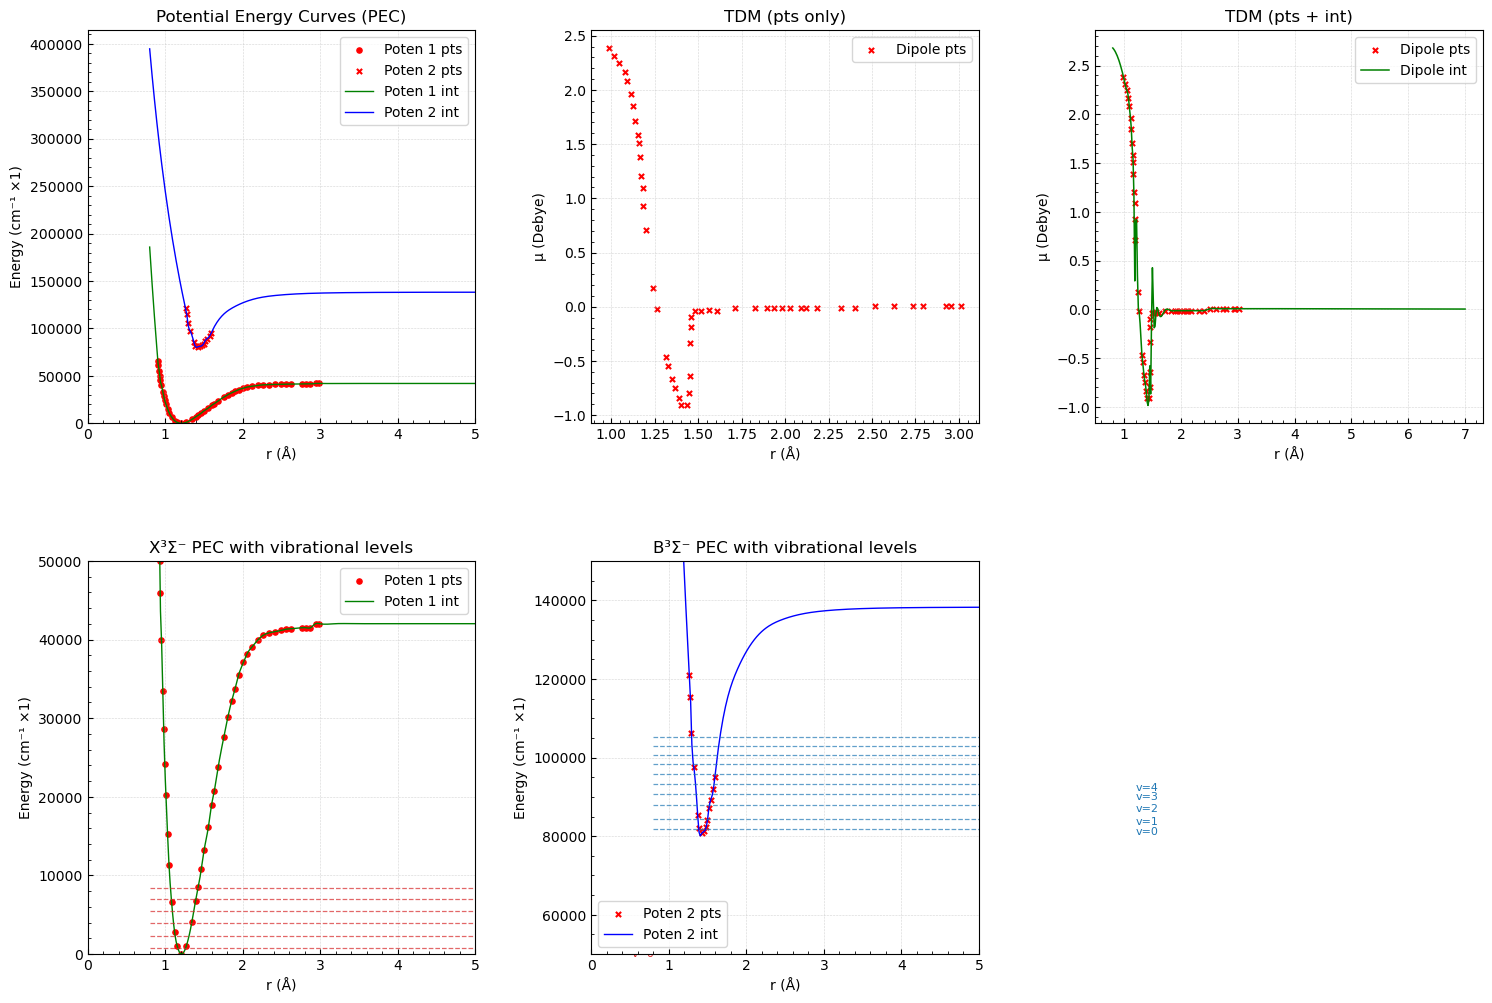

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np   # (already imported earlier, but kept for completeness)

# ── Figure layout: 2 rows × 3 columns ─────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(
    2, 3,               # 2 rows, 3 columns
    height_ratios=[1, 1],
    hspace=0.35, wspace=0.30
)

# Top row (original three-panel layout)
ax_pec        = fig.add_subplot(gs[0, 0])
ax_tdm        = fig.add_subplot(gs[0, 1])
ax_tdm_input  = fig.add_subplot(gs[0, 2])

# Bottom row (one PEC-with-levels panel per state)
ax_x_levels   = fig.add_subplot(gs[1, 0])
ax_b_levels   = fig.add_subplot(gs[1, 1])
fig.add_subplot(gs[1, 2]).axis("off")  # leave last cell blank

# ── Top-row plots ──────────────────────────────────────────
# PEC panel
ax_pec.scatter(pot1_pts[:, 0], pot1_pts[:, 1] * ENERGY_SCALE,
               s=14, marker="o",  color="red",   label="Poten 1 pts")
ax_pec.scatter(pot2_pts[:, 0], pot2_pts[:, 1] * ENERGY_SCALE,
               s=14, marker="x",  color="red",   label="Poten 2 pts")
ax_pec.plot(_r_tbl, pot1_int * ENERGY_SCALE,
            lw=1,  color="green", linestyle="-", label="Poten 1 int")
ax_pec.plot(_r_tbl, pot2_int * ENERGY_SCALE,
            lw=1,  color="blue",  linestyle="-", label="Poten 2 int")
ax_pec.set_xlabel("r (Å)")
ax_pec.set_ylabel(f"Energy (cm⁻¹ ×{ENERGY_SCALE:g})")
ax_pec.set_title("Potential Energy Curves (PEC)")
ax_pec.set_ylim(bottom=0)  # start at zero
ax_pec.set_xlim(0,5)   # start at zero
ax_pec.minorticks_on(); ax_pec.tick_params(which='both', direction='in')
ax_pec.legend(); ax_pec.grid(ls=":", lw=0.4)

# TDM panels
ax_tdm.scatter(dip_pts[:, 0], dip_pts[:, 1],
               s=14, marker="x", color="red", label="Dipole pts")
ax_tdm.set_xlabel("r (Å)"); ax_tdm.set_ylabel("μ (Debye)")
ax_tdm.set_title("TDM (pts only)")
ax_tdm.minorticks_on(); ax_tdm.tick_params(which='both', direction='in')
ax_tdm.legend(); ax_tdm.grid(ls=":", lw=0.4)

ax_tdm_input.scatter(dip_pts[:, 0], dip_pts[:, 1],
                     s=14, marker="x", color="red",   label="Dipole pts")
ax_tdm_input.plot(dip_r_int, dip_mu_int,
                  lw=1.1, linestyle="-", color="green", label="Dipole int")
ax_tdm_input.set_xlabel("r (Å)"); ax_tdm_input.set_ylabel("μ (Debye)")
ax_tdm_input.set_title("TDM (pts + int)")
ax_tdm_input.minorticks_on(); ax_tdm_input.tick_params(which='both', direction='in')
ax_tdm_input.legend(); ax_tdm_input.grid(ls=":", lw=0.4)

# ── Helper: overlay vibrational levels on a PEC axis ───────
def _add_vib_levels(axis, r_grid, energies, color, label_prefix):
    r_min, r_max = r_grid.min(), r_grid.max()
    for v, Ev in enumerate(energies):
        axis.hlines((Ev+ZPE) * ENERGY_SCALE, r_min, r_max, # Add ZPE
                    colors=color, linestyles="--", linewidth=0.9, alpha=0.7)
        if v < 5:
            
            axis.text(r_max + 0.02, Ev * ENERGY_SCALE, f"{label_prefix}v={v}",
                    va="center", ha="left", fontsize=8, color=color)

# ── Bottom-row: PEC + vibrational levels (X and B) ─────────
# X-state
ax_x_levels.scatter(pot1_pts[:, 0], pot1_pts[:, 1] * ENERGY_SCALE,
                    s=14, marker="o", color="red",   label="Poten 1 pts")
ax_x_levels.plot(_r_tbl, pot1_int * ENERGY_SCALE,
                 lw=1, color="green", label="Poten 1 int")
_add_vib_levels(ax_x_levels, _r_tbl, vib_X, "tab:red", "")
ax_x_levels.set_xlabel("r (Å)")
ax_x_levels.set_xlim(0,5)  
ax_x_levels.set_ylim(0,50000)  
ax_x_levels.set_ylabel(f"Energy (cm⁻¹ ×{ENERGY_SCALE:g})")
ax_x_levels.set_title("X³Σ⁻ PEC with vibrational levels")
ax_x_levels.minorticks_on(); ax_x_levels.tick_params(which='both', direction='in')
ax_x_levels.legend(); ax_x_levels.grid(ls=":", lw=0.4)

# B-state
ax_b_levels.scatter(pot2_pts[:, 0], pot2_pts[:, 1] * ENERGY_SCALE,
                    s=14, marker="x", color="red",   label="Poten 2 pts")
ax_b_levels.plot(_r_tbl, pot2_int * ENERGY_SCALE,
                 lw=1, color="blue", label="Poten 2 int")
_add_vib_levels(ax_b_levels, _r_tbl, vib_B, "tab:blue", "")
ax_b_levels.set_xlabel("r (Å)")
ax_b_levels.set_xlim(0,5)  
ax_b_levels.set_ylim(50000,150000)  
ax_b_levels.set_ylabel(f"Energy (cm⁻¹ ×{ENERGY_SCALE:g})")
ax_b_levels.set_title("B³Σ⁻ PEC with vibrational levels")
ax_b_levels.minorticks_on(); ax_b_levels.tick_params(which='both', direction='in')
ax_b_levels.legend(); ax_b_levels.grid(ls=":", lw=0.4)

plt.tight_layout()
plt.show()


In [3]:
# print vibrational energies 0 through 4 and then 19 for reference for both electronic states
print("\nVibrational energies (X state):")
for v in range(5):
    print(f"  v={v}: {vib_X[v] * ENERGY_SCALE:.2f} cm⁻¹")
print(f"  v=19: {vib_X[19] * ENERGY_SCALE:.2f} cm⁻¹")
print("\nVibrational energies (B state):")  
for v in range(5):
    print(f"  v={v}: {vib_B[v] * ENERGY_SCALE:.2f} cm⁻¹")
print(f"  v=19: {vib_B[19] * ENERGY_SCALE:.2f} cm⁻¹")
# End of script


Vibrational energies (X state):
  v=0: 0.00 cm⁻¹
  v=1: 1556.62 cm⁻¹
  v=2: 3086.31 cm⁻¹
  v=3: 4596.96 cm⁻¹
  v=4: 6084.31 cm⁻¹
  v=19: 25621.39 cm⁻¹

Vibrational energies (B state):
  v=0: 49401.49 cm⁻¹
  v=1: 50075.84 cm⁻¹
  v=2: 50748.95 cm⁻¹
  v=3: 51382.16 cm⁻¹
  v=4: 51980.83 cm⁻¹
  v=19: 57099.33 cm⁻¹
